In [58]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
df = pd.read_csv('../../../data/processed/final_dataset.csv')
df.head()

,sustainability_score,total_renewal_score_new,last_years_price,auto_renewal_score,status_scores,anchoring_score,tenure_scores,proforma_auto_renewal,proforma_world_pay_token,proforma_date,current_anchorings,payment_timeframe,registration_date,proforma_audit_status,renewal_score_at_release,proforma_approved_lists,tenure_years,prospect_renewal_date,starting_net,starting_vat,starting_gross,starting_membership_net,starting_package_net,starting_pqq_net,membership_net,package_net,pqqnet,total_amount,last_renewal,last_total_net_paid,last_connections,renewal_year,is_first_year,has_discount,discount_pct,price_increase_abs,price_increase_pct,price_increased_flag,band_ordinal,last_band_ordinal,band_changed,band_upgraded,band_downgraded,tenure_group_ordinal,anchor_group_ordinal,membership_status_ordinal,has_auto_renewal,has_world_pay_token,payment_method_bacs,payment_method_card,payment_method_cheque,payment_method_unknown,payment_method_world_pay,proforma_account_stage_membership_only,proforma_account_stage_published,proforma_account_stage_renewal_process,proforma_account_stage_retired,proforma_account_stage_suspended,proforma_account_stage_unknown,proforma_account_stage_vetting,churn,rc_14d_total_calls,rc_14d_inbound_calls,rc_14d_max_call_number,membership_renewal_decision,desire_to_cancel_encoded,customer_response_encoded,serious_complaint,other_complaint,complaint_count,discussion_on_price_increase,renewal_impact_due_to_price_increase,discount_or_waiver_requested,discount_offered,price_pressure_flag,price_range_discussed_flag,percentage_price_increase_mentioned,monetary_price_increase_mentioned,explicit_competitor_mention,explicit_switching_intent,mentioned_competitors,price_switching_mentioned,competitor_better_value,competitor_similar_value,competitor_better_service,competitor_cheaper,competitor_signal_count,competitor_threat_flag,agent_renewal_initiation,agent_flagged_membership_status_alert,agent_active_retention,call_reschedule_request,topic_by_customer,topic_by_agent,customer_asked_for_justification,rc_high_risk_call,rc_14d_outbound_calls,crm_sentiment_encoded,crm_dissatisfied_flag,crm_satisfied_flag,crm_contractor_sentiment_score,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_competitors_mentioned,crm_platform_issues_raised,crm_membership_overdue,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,crm_dts_or_ssip_mentioned,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_contractor_engagement,crm_customer_payment_intention,crm_agent_chased_contractor,crm_accreditation_issues,crm_agent_chase_count,crm_auto_renewal_status,crm_membership_level_ordinal,high_risk_email,emails_dissatisfaction_issue_count,engagement_score,sentiment_score_valid,email_count,cc_calls_14d_total_calls,cc_calls_14d_inbound_calls,cc_sentiment_encoded,cc_dissatisfied_flag,cc_contractor_sentiment_start_score,cc_contractor_sentiment_end_score,cc_contractor_sentiment_overall_score,cc_customer_issues_concerns,cc_business_struggles_financial_hardship,cc_login_issues,cc_platform_issues,cc_dissatisfaction_time_to_complete,cc_process_complexity_concerns,cc_questions_harder_than_expected,cc_dissatisfaction_support,cc_pricing_mentioned,cc_pricing_sentiment_impact,cc_refund_discussed,cc_contractor_suggest_leave,cc_contractor_complained,cc_urgency_getting_on_site,cc_chasing_response,cc_questionnaire_completion,cc_care_package_discussed,cc_external_consultant,cc_agent_cross_sell_attempt,cc_issues_within_questionnaire,sentiment_improved,sentiment_worsened,sentiment_change,cc_high_risk_call,cc_dissatisfaction_issue_count,pricing_pressure_flag,cc_care_package_assisted,cc_care_package_express,cc_care_package_not_discussed,cc_care_package_premier,cc_care_package_standard,cc_care_package_unknown,cc_call_initiated_by_agent,cc_call_initiated_by_customer,cc_call_initiated_by_not_relevant,cc_call_init

###  Data Leakage Mitigation

The following columns are being dropped due to potential data leakage, as they represent information that would likely only be available during or after the renewal process:

*   `membership_renewal_decision`
*   `total_renewal_score_new`
*   `status_scores`
*   `renewal_score_at_release`
*   `membership_status_ordinal`
*   `auto_renewal_score`

In [59]:
# Columns identified as potential data leakage
leakage_cols = [
    "total_renewal_score_new",
    "status_scores",
    "renewal_score_at_release",
    "membership_status_ordinal",
    "auto_renewal_score"
]

# Drop leakage columns
df = df.drop(columns=leakage_cols, errors="ignore")
print(df.shape)


(113769, 170)


**DATA SPLIT**

In [60]:
X = df.drop(columns=["churn"])

# keep only numeric columns
X = X.select_dtypes(include=[np.number])

y = df["churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(91015, 164) (22754, 164)


In [61]:
# from sklearn.model_selection import train_test_split

# X = df.drop(columns=["churn"])
# y = df["churn"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# print(X_train.shape, X_test.shape)

In [62]:
# Sanity check for Stratified sampling
print("Train churn ratio:")
print(y_train.value_counts(normalize=True))

print("\nTest churn ratio:")
print(y_test.value_counts(normalize=True))

Train churn ratio:
churn
0    0.889271
1    0.110729
Name: proportion, dtype: float64

Test churn ratio:
churn
0    0.889294
1    0.110706
Name: proportion, dtype: float64


### Logistic Regression Model

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("LR ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))

LR ROC-AUC: 0.9656665188403076
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     20235
           1       0.53      0.90      0.66      2519

    accuracy                           0.90     22754
   macro avg       0.76      0.90      0.80     22754
weighted avg       0.94      0.90      0.91     22754



e:\JMAN\churn-prediction-project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Random Forest Classifier Model

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

RF ROC-AUC: 0.9985887045947709
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     20235
           1       0.89      0.98      0.93      2519

    accuracy                           0.98     22754
   macro avg       0.94      0.98      0.96     22754
weighted avg       0.99      0.98      0.98     22754



### XGBoost Classifier Model

In [51]:
from xgboost import XGBClassifier

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGB ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

XGB ROC-AUC: 0.9998390880163243
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20235
           1       0.97      1.00      0.98      2519

    accuracy                           1.00     22754
   macro avg       0.99      1.00      0.99     22754
weighted avg       1.00      1.00      1.00     22754



### Model Performance Comparison

In [52]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# Logistic Regression
lr_auc = roc_auc_score(y_test, y_prob_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Random Forest
rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# XGBoost
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [lr_auc, rf_auc, xgb_auc],
    "Precision": [lr_precision, rf_precision, xgb_precision],
    "Recall": [lr_recall, rf_recall, xgb_recall],
    "F1-Score": [lr_f1, rf_f1, xgb_f1]
})

print(comparison)

                 Model   ROC-AUC  Precision    Recall  F1-Score
0  Logistic Regression  0.965667   0.525087  0.901548  0.663647
1        Random Forest  0.998589   0.887137  0.982930  0.932580
2              XGBoost  0.999839   0.971738  0.996427  0.983928


## Model Explainability and Feature Importance

To understand *why* our churn prediction models are making their decisions, we'll delve into **model explainability**. This involves two key approaches:

1.  **SHAP Analysis (SHapley Additive exPlanations)**: We'll apply SHAP to our best-performing XGBoost model. This technique helps us understand how each feature contributes to an individual prediction, showing not only the magnitude but also the direction of its impact on the churn probability.

2.  **Traditional Feature Importance**: We will also examine feature importance directly from both the Logistic Regression and XGBoost models:
    *   For **Logistic Regression**, we'll analyze the coefficients, indicating the strength and direction of the relationship between each feature and the log-odds of churn.
    *   For **XGBoost**, we'll use its built-in `feature_importances_` attribute, quantifying how much each feature contributes to the model's overall predictive power.

### SHAP Analysis (XGBoost)

SHAP provides insights into how features influence the XGBoost model's predictions. The summary plots show overall feature importance and how individual feature values push predictions towards or away from churn.


SHAP Summary Plot (Feature Importance and Direction of Impact):


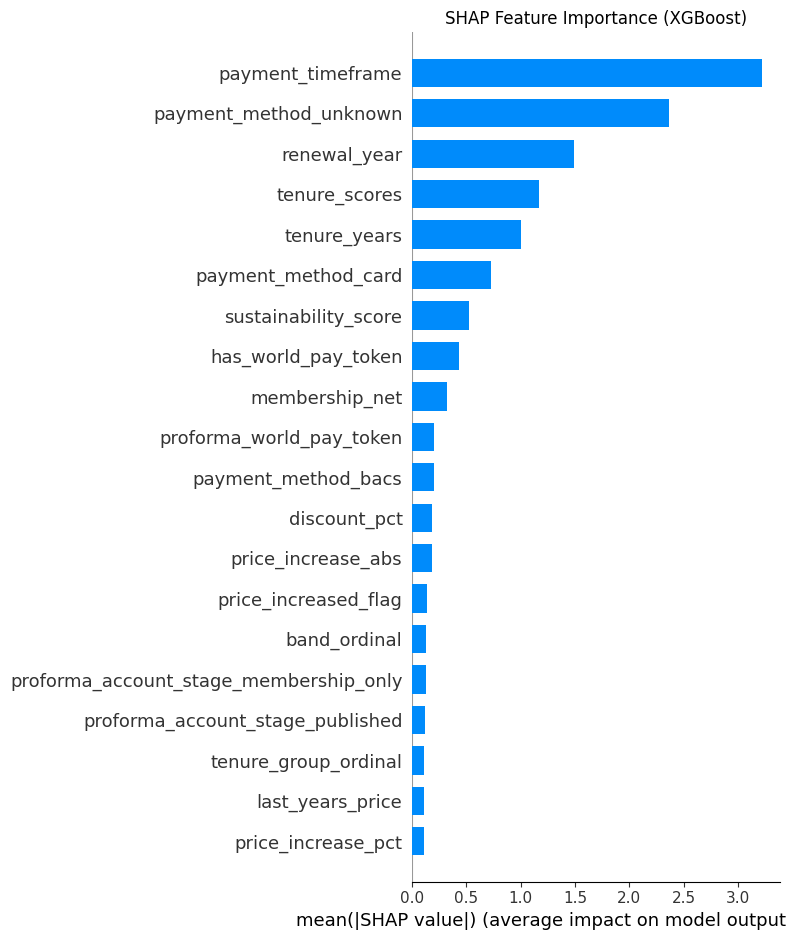

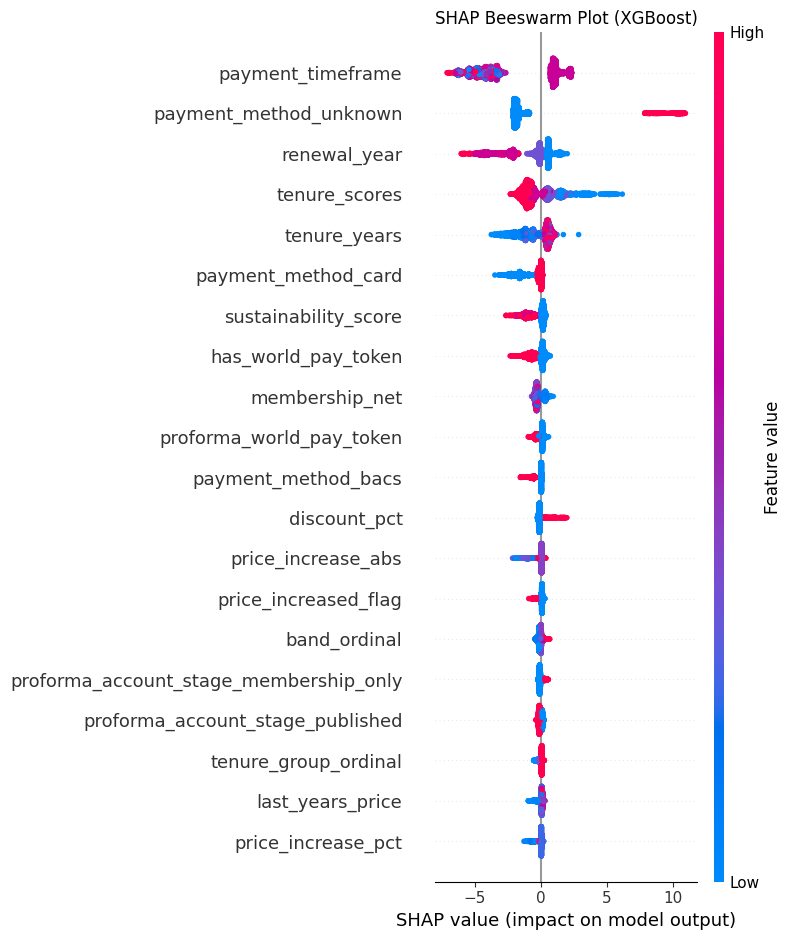

In [53]:
import shap

sample_size = 5000
if X_test.shape[0] > sample_size:
    X_test_sampled = X_test.sample(n=sample_size, random_state=42)
else:
    X_test_sampled = X_test

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_sampled)

print("\nSHAP Summary Plot (Feature Importance and Direction of Impact):")
shap.summary_plot(shap_values, X_test_sampled, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test_sampled, show=False)
plt.title('SHAP Beeswarm Plot (XGBoost)')
plt.tight_layout()
plt.show()


SHAP Dependence Plots for Top Features:


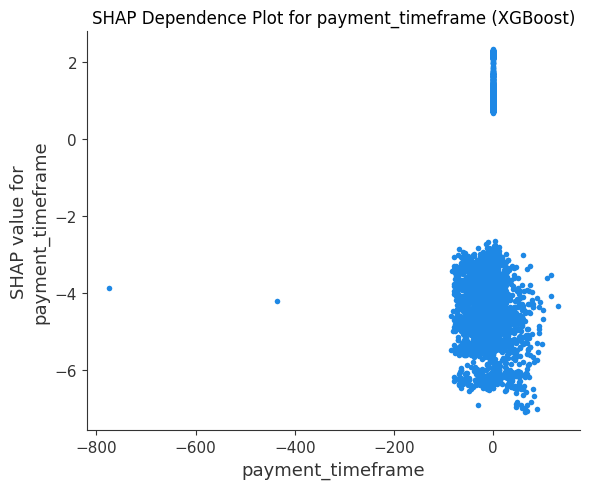

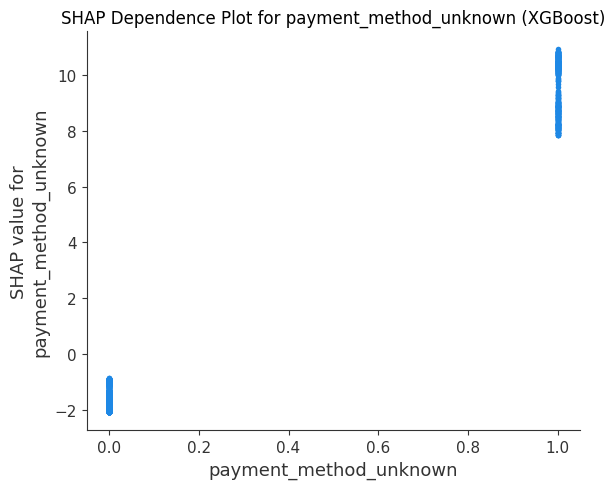

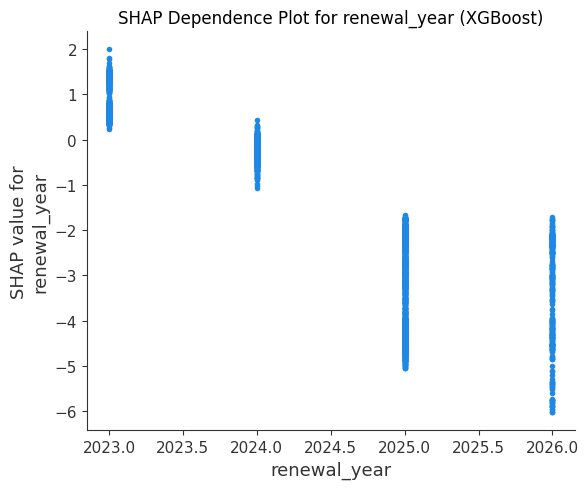

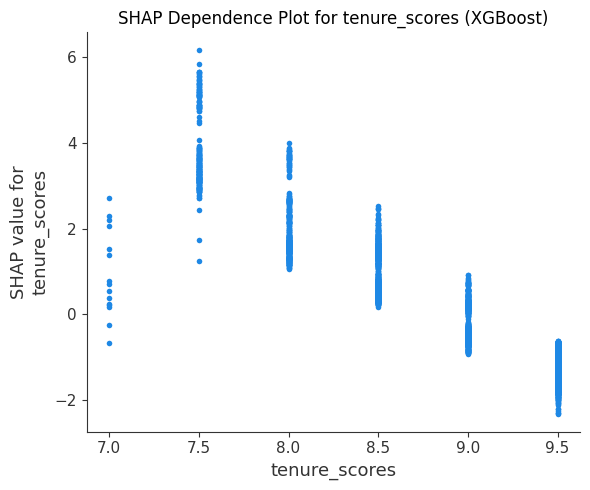

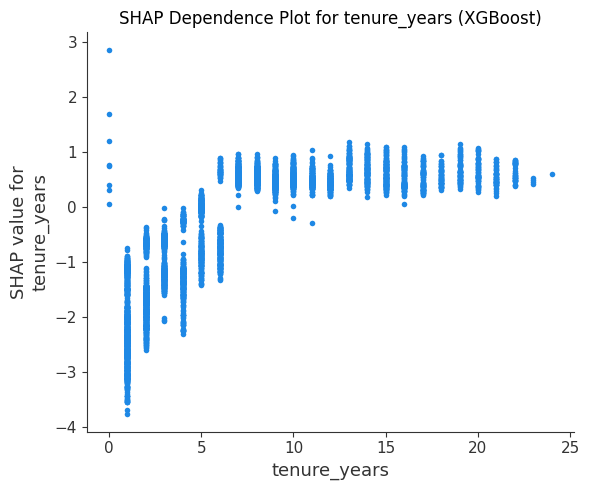

In [54]:
print("\nSHAP Dependence Plots for Top Features:")

if isinstance(shap_values, list):
    abs_shap_values = np.abs(shap_values[1])
else:
    abs_shap_values = np.abs(shap_values)

feature_importance_shap = pd.DataFrame({
    'feature': X_test_sampled.columns,
    'shap_abs_mean': abs_shap_values.mean(axis=0)
}).sort_values(by='shap_abs_mean', ascending=False)

top_features_shap = feature_importance_shap['feature'].head(5).tolist()

for feature in top_features_shap:
    if isinstance(shap_values, list):
        shap.dependence_plot(feature, shap_values[1], X_test_sampled, interaction_index=None, show=False)
    else:
        shap.dependence_plot(feature, shap_values, X_test_sampled, interaction_index=None, show=False)
    plt.title(f'SHAP Dependence Plot for {feature} (XGBoost)')
    plt.tight_layout()
    plt.show()

### Traditional Feature Importance

Here, we examine feature importance from Logistic Regression coefficients and XGBoost's built-in feature importance scores.

In [55]:
print("\nLogistic Regression Feature Importance (Absolute Coefficients):")

lr_coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values(by='coefficient', ascending=False)

print('\nTop 10 Positive Coefficients:')
display(lr_coefficients.head(10))

print('\nTop 10 Negative Coefficients:')
display(lr_coefficients.tail(10))

abs_lr_coefficients = lr_coefficients.copy()
abs_lr_coefficients['coefficient'] = abs_lr_coefficients['coefficient'].abs()
print('\nTop 10 Absolute Coefficients (Overall Importance):')
display(abs_lr_coefficients.sort_values(by='coefficient', ascending=False).head(10))


Logistic Regression Feature Importance (Absolute Coefficients):

Top 10 Positive Coefficients:


,feature,coefficient
41,payment_method_unknown,2.378101
43,proforma_account_stage_membership_only,0.827933
113,emails_dissatisfaction_issue_count,0.504388
112,high_risk_email,0.380825
109,crm_agent_chase_count,0.352325
8,proforma_approved_lists,0.340797
91,crm_contractor_suggested_leave,0.340587
116,email_count,0.246241
162,has_email,0.242216
24,has_discount,0.237661



Top 10 Negative Coefficients:


,feature,coefficient
5,proforma_world_pay_token,-0.550183
121,cc_contractor_sentiment_start_score,-0.765934
44,proforma_account_stage_published,-0.926902
38,payment_method_bacs,-0.994357
122,cc_contractor_sentiment_end_score,-1.124649
123,cc_contractor_sentiment_overall_score,-1.171217
39,payment_method_card,-1.304316
3,tenure_scores,-1.581449
37,has_world_pay_token,-1.582697
0,sustainability_score,-2.137398



Top 10 Absolute Coefficients (Overall Importance):


,feature,coefficient
41,payment_method_unknown,2.378101
0,sustainability_score,2.137398
37,has_world_pay_token,1.582697
3,tenure_scores,1.581449
39,payment_method_card,1.304316
123,cc_contractor_sentiment_overall_score,1.171217
122,cc_contractor_sentiment_end_score,1.124649
38,payment_method_bacs,0.994357
44,proforma_account_stage_published,0.926902
43,proforma_account_stage_membership_only,0.827933



XGBoost Feature Importance:


,feature,importance
41,payment_method_unknown,0.377950
7,payment_timeframe,0.214661
22,renewal_year,0.069681
23,is_first_year,0.051580
38,payment_method_bacs,0.038976
37,has_world_pay_token,0.038229
39,payment_method_card,0.030769
0,sustainability_score,0.030048
42,payment_method_world_pay,0.021898
116,email_count,0.017348


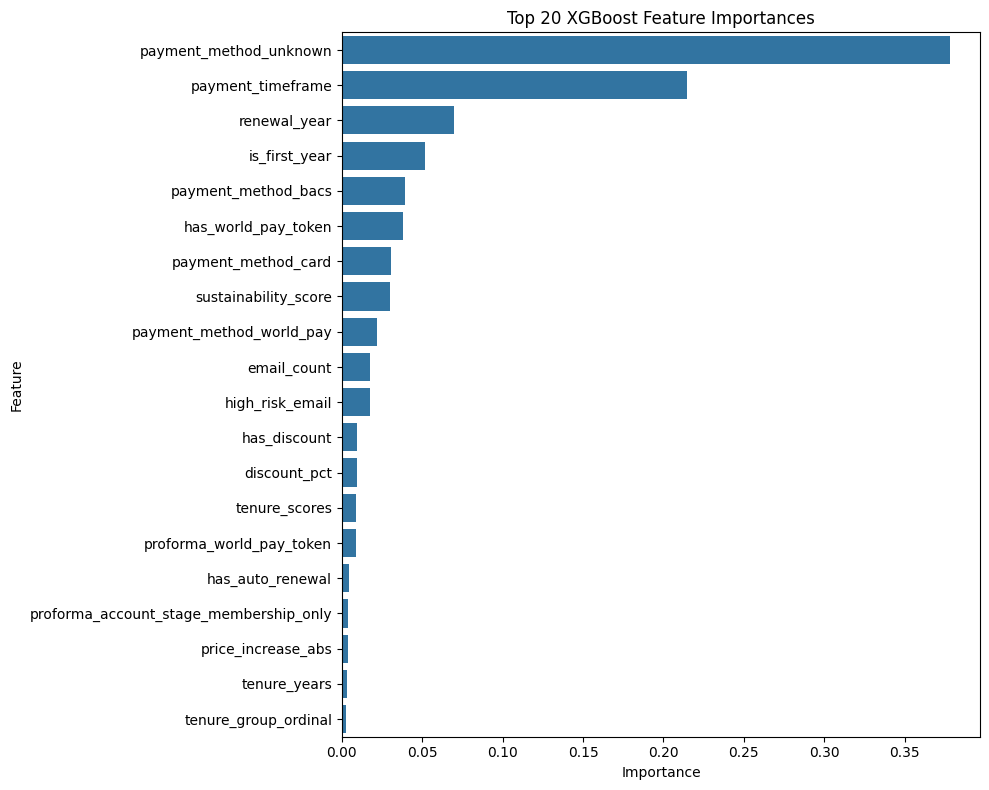

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

print("\nXGBoost Feature Importance:")

xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

display(xgb_importance.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=xgb_importance.head(20))
plt.title('Top 20 XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Model Performance: ROC Curve Comparison

This plot compares the ROC (Receiver Operating Characteristic) curves for the Logistic Regression, Random Forest, and XGBoost models. A higher AUC (Area Under the Curve) indicates better model performance in distinguishing between the positive (churned) and negative (non-churned) classes. The curve illustrates the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate (1-Specificity) at various threshold settings.

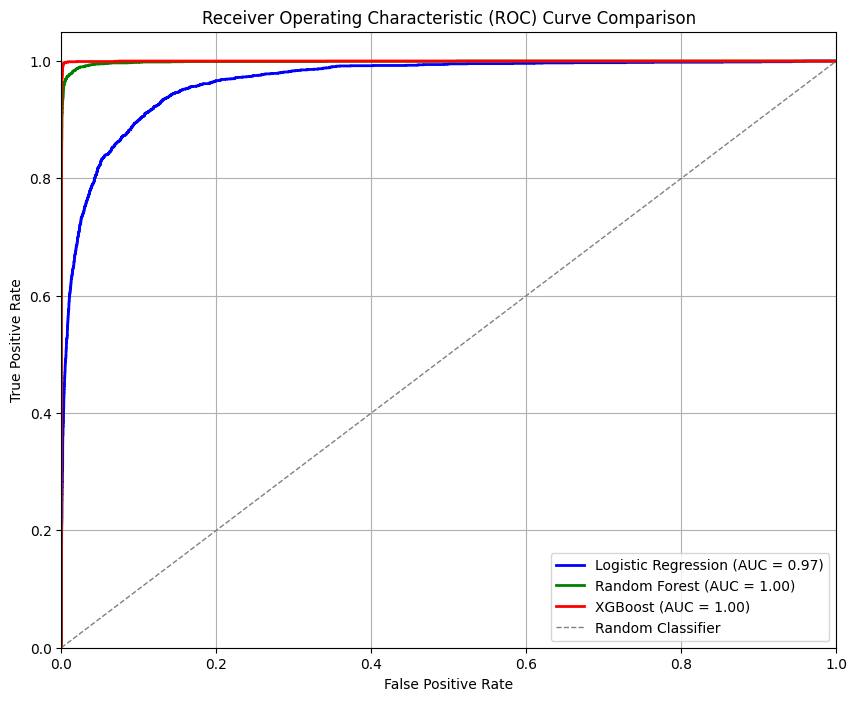

In [57]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plot ROC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Plot ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Plot ROC for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()